# Fig5_nichespace_clustering.ipynb

This notebook demonstrates clustering of species niche spaces, drawing dendrograms, visualizing average niche spaces, and performing related calculations and plots.

In [1]:
from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail
import yaml
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.decomposition import PCA
import math
import feather
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, set_link_color_palette
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib as mpl
from scipy.stats import skewnorm
import matplotlib.ticker as mtick
from matplotlib.ticker import ScalarFormatter

# Set default matplotlib parameters.
set_mpl_defaults()

## Define run and experiment IDs
The PlotUtlis class uses these IDs to locate various data and configuration paths.

In [2]:
run_id = 'a21e809cf92c477c8e6f67a638adcb03'
exp_id = '560401789505105998'

## Initialize PlotUtlis
This instantiates the PlotUtlis object, which provides convenience methods for data loading, saving, and plotting.

In [3]:
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

## Create directory for niche space clustering plots
Ensures the target directory exists for saving our clustering figures.

In [4]:
create_folder(PU.plot_path_nichespace_clustering)

### Translate species name to Chinese

In [5]:
# df_name = pd.read_csv('./raw/data/nvdimp_subplot.csv')
# sciname = list(set(df_name.scientificName))
# chiname = [df_name[df_name['scientificName'] == s_n]['vernacularName'].value_counts().idxmax() if len(set(df_name[df_name['scientificName'] == s_n]['vernacularName']))>1 else list(set(df_name[df_name['scientificName'] == s_n]['vernacularName']))[0] for s_n in sciname]
# pd.DataFrame({'sciname': sciname, 'chiname': chiname}).to_csv(os.path.join(PU.plot_path_nichespace_clustering, 'change_name.csv'), index = None)

## Retrieve DeepSDM niche space data
Loads precomputed niche space arrays for each species from disk.

In [6]:
# these are TREES
species_list_filter = ['Debregeasia_orientalis', 'Neolitsea_hiiranensis', 'Capparis_micracantha', 'Berberis_mingetsensis', 'Radermachera_sinica', 'Cinnamomum_osmophloeum', 'Cleyera_japonica_var._taipinensis', 'Acer_serrulatum', 'Vaccinium_randaiense', 'Acer_albopurpurascens', 'Polyspora_axillaris', 'Enkianthus_perulatus', 'Machilus_zuihoensis_var._mushaensis', 'Turpinia_formosana', 'Sarcopyramis_napalensis_var._delicata', 'Lithocarpus_harlandii', 'Distyliopsis_dunnii', 'Rubus_formosensis', 'Terminalia_catappa', 'Derris_trifoliata', 'Vernicia_montana', 'Pittosporum_daphniphylloides', 'Trachelospermum_formosanum', 'Macaranga_tanarius', 'Quercus_pachyloma', 'Hydrangea_longifolia', 'Champereia_manillana', 'Dodonaea_viscosa', 'Aeschynanthus_acuminatus', 'Salix_fulvopubescens_var._doii', 'Vernicia_fordii', 'Bombax_ceiba', 'Grewia_rhombifolia', 'Berchemia_lineata', 'Croton_cascarilloides', 'Calocedrus_macrolepis_var._formosana', 'Euonymus_laxiflorus', 'Lepisorus_pseudoussuriensis', 'Actinidia_callosa_var._discolor', 'Crateva_adansonii_subsp._formosensis', 'Vaccinium_kengii', 'Diospyros_oldhamii', 'Castanopsis_eyrei', 'Heptapleurum_heptaphyllum', 'Neolitsea_acuminatissima', 'Ficus_erecta_var._beecheyana', 'Ventilago_leiocarpa', 'Syzygium_densinervium', 'Drypetes_karapinensis', 'Randia_sinensis', 'Lantana_camara', 'Taiwania_cryptomerioides', 'Elaeocarpus_decipiens', 'Ficus_variegata_var._variegata', 'Cayratia_japonica', 'Lagerstroemia_subcostata', 'Ardisia_crenata', 'Triadica_cochinchinensis', 'Kadsura_japonica', 'Albizia_julibrissin', 'Symplocos_koshunensis', 'Nageia_nagi', 'Bretschneidera_sinensis', 'Margaritaria_indica', 'Smilax_bracteata_var._verruculosa', 'Microtropis_japonica', 'Schisandra_arisanensis', 'Euonymus_pallidifolia', 'Oreocnide_pedunculata', 'Ormosia_hengchuniana', 'Aristolochia_kaempferi', 'Osmanthus_matsumuranus', 'Osmanthus_lanceolatus', 'Premna_octonervia', 'Palaquium_formosanum', 'Cinnamomum_insularimontanum', 'Celastrus_kusanoi', 'Syzygium_jambos', 'Hibiscus_syriacus', 'Symplocos_formosana', 'Myrica_adenophora', 'Ficus_subpisocarpa', 'Rubus_kawakamii', 'Camphora_officinarum', 'Actinidia_setosa', 'Zanthoxylum_scandens', 'Lonicera_acuminata', 'Machilus_japonica_var._kusanoi', 'Manihot_esculenta', 'Tetrastigma_bioritsense', 'Ilex_crenata', 'Ilex_tugitakayamensis', 'Styrax_suberifolia', 'Phyllanthus_reticulatus', 'Pistacia_chinensis', 'Cryptomeria_japonica', 'Camellia_oleifera', 'Ardisia_cornudentata_subsp._cornudentata', 'Bridelia_tomentosa', 'Litsea_perrottetii', 'Dimocarpus_longan', 'Mallotus_paniculatus', 'Abies_kawakamii', 'Aucuba_japonica', 'Cleyera_japonica_var._longicarpa', 'Symplocos_caudata', 'Cinnamomum_reticulatum', 'Drypetes_littoralis', 'Stachyurus_himalaicus', 'Juniperus_formosana_var._formosana', 'Cassia_grandis', 'Lasianthus_japonicus', 'Quercus_hypophaea', 'Adinandra_formosana', 'Quercus_gilva', 'Osmanthus_heterophyllus', 'Quercus_longinux', 'Zanthoxylum_pistaciiflorum', 'Callicarpa_tikusikensis', 'Stauntonia_hexaphylla', 'Callicarpa_longissima', 'Heptapleurum_ellipticum', 'Aucuba_chinensis_var._chinensis', 'Parthenocissus_tricuspidata', 'Mallotus_paniculatus_var._formosanus', 'Carpinus_rankanensis', 'Scolopia_oldhamii', 'Broussonetia_papyrifera', 'Lasianthus_bunzanensis', 'Strychnos_cathayensis', 'Cinnamomum_macrostemon', 'Viburnum_plicatum_var._formosanum', 'Bridelia_balansae', 'Rubus_yuliensis', 'Pittosporum_tobira', 'Rhododendron_tashiroi', 'Diospyros_morrisiana', 'Pittosporum_illicioides_var._angustifolium', 'Castanopsis_fargesii', 'Sinopanax_formosanus', 'Actinidia_latifolia', 'Viburnum_urceolatum', 'Melia_azedarach', 'Lindera_aggregata_var._aggregata', 'Leea_philippinensis', 'Fatsia_polycarpa', 'Sambucus_chinensis', 'Phyllanthus_oligospermus', 'Symplocos_congesta_var._theifolia', 'Guettarda_speciosa', 'Tsuga_chinensis_var._formosana', 'Archidendron_lucidum', 'Camellia_japonica', 'Eurycorymbus_cavaleriei', 'Aglaia_elliptifolia', 'Rhododendron_kawakamii', 'Prinsepia_scandens', 'Cinchona_ledgeriana', 'Diospyros_rhombifolia', 'Callicarpa_randaiensis', 'Castanopsis_indica', 'Rhaphiolepis_indica_var._tashiroi', 'Mallotus_japonicus', 'Adinandra_lasiostyla', 'Carpinus_hebestroma', 'Eustigma_oblongifolium', 'Antidesma_japonicum_var._densiflorum', 'Melastoma_candidum', 'Cleyera_japonica_var._japonica', 'Lasianthus_wallichii', 'Aralia_bipinnata', 'Malus_doumeri', 'Euchresta_formosana', 'Aphananthe_aspera', 'Ficus_ampelos', 'Murraya_omphalocarpa', 'Medinilla_formosana', 'Rhododendron_pseudochrysanthum', 'Heptapleurum_taiwanianum', 'Randia_cochinchinensis', 'Photinia_niitakayamensis', 'Litsea_akoensis_var._sasakii', 'Rhododendron_breviperulatum', 'Euonymus_oxyphyllus', 'Koelreuteria_henryi', 'Homalium_cochinchinensis', 'Lithocarpus_glaber', 'Rhamnus_formosana', 'Rhododendron_formosanum', 'Viburnum_erosum', 'Ehretia_resinosa', 'Ardisia_cornudentata_subsp._morrisonensis_var._morrisonensis', 'Rhamnus_nakaharae', 'Pometia_pinnata', 'Stauntonia_obovata', 'Severinia_buxifolia', 'Rhododendron_ovatum_var._lamprophyllum', 'Neolitsea_parvigemma', 'Ficus_esquiroliana', 'Calophyllum_inophyllum', 'Decaspermum_gracilentum', 'Castanopsis_cuspidata_var._carlesii', 'Lithocarpus_kawakamii', 'Symplocos_arisanensis', 'Capparis_floribunda', 'Myrica_rubra', 'Ilex_bioritsensis', 'Vaccinium_wrightii_var._formosanum', 'Ardisia_japonica', 'Machilus_zuihoensis_var._zuihoensis', 'Zanthoxylum_nitidum', 'Tetradium_glabrifolium', 'Syzygium_paucivenium', 'Sycopsis_sinensis', 'Ilex_cochinchinensis', 'Euscaphis_japonica', 'Clerodendrum_canescens', 'Syzygium_buxifolium', 'Boehmeria_densiflora', 'Quercus_repandifolia', 'Premna_microphylla', 'Ficus_ruficaulis_var._antaoensis', 'Illicium_tashiroi', 'Helicia_formosana', 'Viburnum_luzonicum', 'Quercus_sessilifolia', 'Pueraria_montana', 'Lygodium_japonicum', 'Berberis_aristatoserrulata', 'Picrasma_quassioides', 'Photinia_serratifolia_var._ardisiifolia', 'Neolitsea_sericea_var._sericea', 'Astronia_formosana', 'Aralia_finlaysoniana', 'Akebia_longeracemosa', 'Sorbus_randaiensis', 'Berchemia_formosana', 'Neolitsea_buisanensis_fo._buisanensis', 'Arenga_engleri', 'Antidesma_japonicum_var._acutisepalum', 'Melicope_pteleifolia', 'Distylium_gracile', 'Acer_caudatifolium', 'Cunninghamia_lanceolata', 'Photinia_serratifolia_var._serratifolia', 'Elaeagnus_grandifolia', 'Symplocos_nokoensis', 'Ficus_pumila_var._pumila', 'Schizophragma_fauriei', 'Symplocos_cochinchinensis_var._cochinchinensis', 'Euonymus_spraguei', 'Viburnum_taitoense', 'Rhododendron_chilanshanense', 'Quercus_variabilis', 'Pterocarpus_indicus', 'Acer_morrisonense', 'Ilex_lonicerifolia_var._matsudae', 'Itea_parviflora', 'Sabia_swinhoei', 'Blastus_cochinchinensis', 'Alsophila_podophylla', 'Mahonia_japonica', 'Heliotropium_formosanum', 'Rhodomyrtus_tomentosa', 'Cleyera_japonica_var._morii', 'Skimmia_reevesiana', 'Viburnum_formosanum', 'Viburnum_foetidum_var._rectangulatum', 'Phoebe_formosana', 'Heptapleurum_arboricola', 'Leucaena_leucocephala', 'Ficus_fistulosa_fo._benguetensis', 'Embelia_rudis', 'Turpinia_ternata', 'Strobilanthes_longespicatus', 'Paederia_foetida', 'Salix_warburgii', 'Symplocos_trichoclada', 'Acalypha_suirenbiensis', 'Pisonia_umbellifera', 'Camellia_sasanqua', 'Vitex_quinata', 'Acacia_caesia', 'Thespesia_populnea', 'Pourthiaea_beauverdiana_var._notabilis', 'Symplocos_stellaris', 'Erycibe_henryi', 'Prunus_taiwaniana', 'Vaccinium_bracteatum', 'Anneslea_fragrans_var._lanceolata', 'Neolitsea_aciculata_var._variabillima', 'Psidium_guajava', 'Actinidia_rufa', 'Bredia_oldhamii', 'Zanthoxylum_armatum', 'Cornus_kousa', 'Euonymus_carnosus', 'Rhododendron_hyperythrum', 'Viburnum_propinquum', 'Ilex_suzukii', 'Styrax_matsumurae', 'Callicarpa_kochiana', 'Eriobotrya_deflexa', 'Tetrastigma_formosanum', 'Sassafras_randaiense', 'Cornus_macrophylla', 'Tetrastigma_umbellatum', 'Diospyros_japonica', 'Wendlandia_uvariifolia', 'Picea_morrisonicola', 'Urceola_rosea', 'Meliosma_rigida', 'Neolitsea_konishii', 'Deutzia_pulchra', 'Rhamnus_crenata', 'Glochidion_philippicum', 'Ficus_septica', 'Strobilanthes_formosanus', 'Prunus_zippeliana', 'Castanopsis_formosana', 'Vitex_negundo', 'Lithocarpus_corneus', 'Symplocos_modesta', 'Smilax_bracteata_var._bracteata', 'Lithocarpus_amygdalifolius', 'Eurya_strigillosa', 'Deutzia_taiwanensis', 'Millettia_pachycarpa', 'Callicarpa_pilosissima', 'Nageia_fleuryi', 'Lithocarpus_nantoensis', 'Ilex_pubescens', 'Piper_kadsura', 'Vaccinium_merrillianum', 'Gymnema_sylvestre', 'Osmanthus_enervius', 'Castanopsis_fabri', 'Garcinia_multiflora', 'Flueggea_suffruticosa', 'Ventilago_elegans', 'Symplocos_setchuensis', 'Buxus_microphylla_subsp._sinica', 'Aglaia_formosana', 'Vaccinium_japonicum_var._lasiostemon', 'Illicium_arborescens', 'Machilus_obovatifolia', 'Berberis_kawakamii', 'Callicarpa_remotiserrulata', 'Engelhardia_roxburghiana', 'Callicarpa_formosana_var._glabrata', 'Ficus_microcarpa_var._crassifolia', 'Clematis_tashiroi', 'Cordia_aspera', 'Tarenna_gracilipes', 'Meliosma_squamulata', 'Trachelospermum_gracilipes', 'Zelkova_serrata', 'Lasianthus_curtisii', 'Rhaphiolepis_indica_var._hiiranensis', 'Glochidion_zeylanicum_var._zeylanicum', 'Lasianthus_appressihirtus_var._appressihirtus', 'Calamus_beccarii', 'Alsophila_loheri', 'Lithocarpus_lepidocarpus', 'Quercus_globosa', 'Styrax_formosana', 'Diplospora_dubia', 'Sageretia_thea', 'Lasianthus_appressihirtus_var._maximus', 'Symplocos_grandis', 'Vaccinium_emarginatum', 'Sinoadina_racemosa', 'Machilus_pseudolongifolia', 'Toddalia_asiatica', 'Zanthoxylum_schinifolium', 'Rhus_succedanea_var._succedanea', 'Breynia_officinalis_var._officinalis', 'Ficus_punctata', 'Camphora_kanahirae', 'Rhamnus_parvifolia', 'Berberis_morrisonensis', 'Reevesia_formosana', 'Cryptocarya_concinna', 'Ficus_tinctoria', 'Alnus_formosana', 'Machilus_thunbergii', 'Berchemia_racemosa_var._magna', 'Calamus_formosanus', 'Melicope_semecarpifolia', 'Litsea_cubeba', 'Quercus_glauca', 'Dysoxylum_hongkongense', 'Boehmeria_nivea_var._tenacissima', 'Ficus_microcarpa_var._microcarpa', 'Diospyros_philippensis', 'Sphaeropteris_lepifera', 'Lindera_communis', 'Viburnum_integrifolium', 'Viburnum_odoratissimum', 'Malus_hupehensis', 'Sageretia_randaiensis', 'Magnolia_compressa_var._formosana', 'Erythrina_variegata', 'Pittosporum_pentandrum', 'Pourthiaea_villosa_var._parvifolia', 'Eurya_loquaiana', 'Beilschmiedia_erythrophloia', 'Quercus_salicina', 'Camellia_furfuracea', 'Schima_superba_var._kankaoensis', 'Ulmus_parvifolia', 'Fraxinus_insularis', 'Clematis_henryi_var._morii', 'Lasianthus_biflorus', 'Rhamnus_pilushanensis', 'Litsea_acutivena', 'Euonymus_tashiroi', 'Schoepfia_jasminodora', 'Ilex_uraiensis', 'Quercus_tatakaensis', 'Litsea_morrisonensis', 'Smilax_china', 'Jasminum_sinense', 'Medinilla_taiwaniana', 'Camellia_transarisanensis', 'Ehretia_acuminata', 'Ulmus_uyematsui', 'Lithocarpus_synbalanos', 'Ficus_caulocarpa', 'Castanopsis_kawakamii', 'Alsophila_spinulosa', 'Paulownia_fortunei', 'Gaultheria_cumingiana', 'Ilex_sugerokii_var._brevipedunculata', 'Styrax_hayataianus', 'Bauhinia_variegata', 'Prunus_transarisanensis_var._takasagomontana', 'Symplocos_chinensis', 'Syzygium_kusukusense', 'Buxus_liukiuensis', 'Pouzolzia_elegans', 'Celtis_sinensis', 'Citrus_reticulata_var._depressa', 'Elaeocarpus_japonicus', 'Pentapanax_castanopsidicola', 'Phellodendron_amurense_var._wilsonii', 'Trichodesma_calycosum', 'Cinnamomum_brevipedunculatum', 'Spiraea_thunbergii', 'Lasianthus_fordii', 'Chamaecyparis_obtusa_var._formosana', 'Neolitsea_aciculata_var._aciculata', 'Clematis_uncinata_var._uncinata', 'Rhododendron_rubropunctatum', 'Neonauclea_reticulata', 'Miscanthus_floridulus', 'Ilex_ficoidea', 'Symplocos_heishanensis', 'Prunus_obtusata', 'Camphora_micrantha', 'Anodendron_affine', 'Celtis_biondii', 'Pandanus_odorifer', 'Eurya_acuminata', 'Nekemias_cantoniensis', 'Artocarpus_treculianus', 'Hydrangea_angustipetala', 'Pileostegia_viburnoides', 'Sarcandra_glabra', 'Brucea_javanica', 'Glochidion_zeylanicum_var._lanceolatum', 'Hydrangea_anomala', 'Callicarpa_hypoleucophylla', 'Citrus_maxima', 'Damnacanthus_angustifolius', 'Ampelopsis_brevipedunculata_var._hancei', 'Leea_guineensis', 'Fissistigma_glaucescens', 'Xylosma_congesta', 'Liquidambar_formosana', 'Camellia_caudata', 'Pittosporum_illicioides_var._illicioides', 'Quercus_longinux_var._kuoi', 'Maytenus_diversifolia', 'Ilex_arisanensis', 'Microlepia_×_bipinnata', 'Magnolia_kachirachirai', 'Photinia_lucida', 'Eurya_hayatae', 'Symplocos_congesta_var._congesta', 'Celastrus_hindsii', 'Ardisia_sieboldii', 'Chrinephrium_insulare', 'Firmiana_simplex', 'Litsea_acuminata', 'Rhus_sylvestris', 'Smilax_planipedunculata', 'Premna_serratifolia', 'Cephalotaxus_wilsoniana', 'Prunus_matuurae', 'Hydrangea_paniculata', 'Ilex_maximowicziana', 'Juglans_cathayensis', 'Amentotaxus_formosana', 'Symplocos_sonoharae_var._sonoharae', 'Tetradium_ruticarpum', 'Castanopsis_cuspidata_fo._sessilis', 'Magnolia_compressa_var._compressa', 'Ilex_goshiensis', 'Strobilanthes_flexicaulis', 'Celtis_nervosa', 'Symplocos_theophrastifolia', 'Cunninghamia_konishii', 'Prunus_spinulosa', 'Eurya_crenatifolia', 'Cinnamomum_subavenium', 'Stephanandra_incisa', 'Capparis_sikkimensis_subsp._formosana', 'Camellia_transnokoensis', 'Epipremnum_pinnatum', 'Derris_laxiflora', 'Clausena_excavata', 'Daphne_arisanensis', 'Pinus_armandii_var._mastersiana', 'Antidesma_hiiranense', 'Citrus_×_taiwanica', 'Ehretia_longiflora', 'Ilex_yunnanensis', 'Callicarpa_dichotoma', 'Glycosmis_citrifolia', 'Ilex_formosana', 'Camellia_formosensis', 'Citrus_tachibana', 'Smilax_corbularia', 'Skimmia_arisanensis', 'Casearia_membranacea', 'Osmanthus_marginatus', 'Zanthoxylum_avicennae', 'Celastrus_punctatus', 'Dendrocalamus_latiflorus', 'Alniphyllum_pterospermum', 'Podocarpus_fasciculus', 'Blumea_lacera', 'Gaultheria_itoana', 'Amischotolype_hispida', 'Mucuna_macrocarpa', 'Photinia_serratifolia_var._lasiopetala', 'Sloanea_formosana', 'Eurya_chinensis', 'Maesa_japonica', 'Murraya_euchrestifolia', 'Pongamia_pinnata', 'Rhododendron_rubropilosum_var._rubropilosum', 'Podocarpus_macrophyllus_var._maki', 'Acalypha_matudae', 'Daphniphyllum_glaucescens_subsp._oldhamii', 'Melanolepis_multiglandulosa', 'Machilus_konishii', 'Viburnum_parvifolium', 'Myrsine_seguinii', 'Salix_fulvopubescens_var._fulvopubescens', 'Hymenophyllum_fujisanense', 'Quercus_championii', 'Falcataria_falcata', 'Trema_orientalis', 'Abelia_chinensis_var._ionandra', 'Helicia_rengetiensis', 'Mallotus_repandus', 'Camellia_nokoensis', 'Callerya_nitida_var._nitida', 'Barthea_barthei', 'Mahonia_oiwakensis', 'Callicarpa_remotiflora', 'Tarenna_zeylanica', 'Lithocarpus_dodonaeifolius', 'Dalbergia_benthamii', 'Syzygium_euphlebium', 'Hydrangea_chinensis', 'Celtis_tetrandra', 'Mussaenda_pubescens', 'Symplocos_migoi', 'Psychotria_serpens', 'Strobilanthes_cusia', 'Aralia_decaisneana', 'Symplocos_glauca', 'Pyrenaria_shinkoensis', 'Hibiscus_taiwanensis', 'Fissistigma_oldhamii', 'Distylium_racemosum', 'Pueraria_montana_var._lobata', 'Castanopsis_uraiana', 'Glochidion_rubrum', 'Rhododendron_ovatum_var._ovatum', 'Platycarya_strobilacea', 'Prunus_buergeriana', 'Alangium_chinense', 'Machilus_philippinensis', 'Marsdenia_formosana', 'Bredia_gibba', 'Pilea_aquarum_subsp._brevicornuta', 'Ficus_formosana_fo._formosana', 'Rubus_mesogaeus', 'Wikstroemia_lanceolata', 'Ilex_lonicerifolia_var._lonicerifolia', 'Hibiscus_tiliaceus', 'Tetrapanax_papyriferus', 'Lasianthus_cyanocarpus', 'Hiptage_benghalensis', 'Piper_sintenense', 'Quercus_tarokoensis', 'Eurya_nitida_var._nitida', 'Embelia_lenticellata', 'Barringtonia_asiatica', 'Rhamnus_chingshuiensis_var._tashanensis', 'Lasianthus_chinensis', 'Litsea_coreana', 'Phanera_championii', 'Eurya_leptophylla', 'Maclura_cochinchinensis', 'Diospyros_eriantha', 'Elaeagnus_glabra', 'Ficus_virgata', 'Claoxylon_brachyandrum', 'Deutzia_cordatula', 'Wikstroemia_indica', 'Triadica_sebifera', 'Ficus_nervosa', 'Ligustrum_liukiuense', 'Lindera_akoensis', 'Meliosma_callicarpifolia', 'Daphniphyllum_membranaceum', 'Lithocarpus_shinsuiensis', 'Quercus_spinosa', 'Embelia_laeta_var._papilligera', 'Podocarpus_nakaii', 'Meliosma_rhoifolia', 'Christella_parasitica', 'Strobilanthes_rankanensis', 'Prunus_transarisanensis', 'Eurya_glaberrima', 'Helicia_cochinchinensis', 'Saurauia_oldhamii', 'Lasianthus_obliquinervis_var._obliquinervis', 'Hydrangea_aspera', 'Symplocos_shilanensis', 'Viburnum_arboricolum', 'Prunus_phaeosticta_var._ilicifolia', 'Rubus_pyrifolius', 'Derris_elliptica', 'Ailanthus_altissima_var._tanakai', 'Glochidion_acuminatum', 'Hernandia_nymphiifolia', 'Actinidia_arguta', 'Fraxinus_griffithii', 'Spiraea_prunifolia', 'Dendrocnide_meyeniana', 'Eurya_gnaphalocarpa', 'Camellia_assamica', 'Premna_odorata', 'Musa_basjoo_var._formosana', 'Lindera_megaphylla', 'Broussonetia_monoica', 'Litsea_lii_var._lii', 'Itea_oldhamii', 'Coriaria_japonica_subsp._intermedia', 'Fagus_hayatae', 'Symplocos_sasakii', 'Ligustrum_sinense', 'Bischofia_javanica', 'Ternstroemia_gymnanthera', 'Callicarpa_formosana_var._longifolia', 'Ardisia_cornudentata_subsp._morrisonensis_var._stenosepala', 'Idesia_polycarpa', 'Gardenia_jasminoides', 'Cornus_controversa', 'Ilex_micrococca', 'Rhus_ambigua', 'Podocarpus_macrophyllus_var._macrophyllus', 'Embelia_laeta', 'Camellia_brevistyla', 'Litsea_hypophaea', 'Schima_superba_var._superba', 'Anodendron_benthamianum', 'Wendlandia_formosana', 'Rhaphiolepis_indica_var._umbellata', 'Wisteriopsis_reticulata_var._reticulata', 'Yushania_niitakayamensis', 'Trochodendron_aralioides', 'Ficus_irisana', 'Ficus_benjamina', 'Lyonia_ovalifolia_var._ovalifolia', 'Morus_australis', 'Mallotus_philippensis', 'Sabia_transarisanensis', 'Castanopsis_kusanoi', 'Acer_palmatum_var._pubescens', 'Lindera_erythrocarpa', 'Ormosia_formosana', 'Elaeagnus_formosana', 'Rhododendron_noriakianum', 'Lasianthus_microstachys', 'Freycinetia_formosana', 'Quercus_stenophylloides', 'Microtropis_fokienensis', 'Damnacanthus_indicus', 'Litchi_chinensis', 'Annona_squamosa', 'Acacia_confusa', 'Camellia_salicifolia', 'Prunus_phaeosticta_var._phaeosticta', 'Maesa_perlaria_var._formosana', 'Cinchona_succirubra', 'Beilschmiedia_tsangii', 'Litsea_akoensis_var._akoensis', 'Pieris_taiwanensis', 'Zanthoxylum_ailanthoides', 'Prunus_campanulata', 'Carpinus_kawakamii', 'Osmanthus_kaoi', 'Brugmansia_suaveolens', 'Wikstroemia_taiwanensis', 'Clerodendrum_trichotomum', 'Litsea_elongata_var._mushaensis', 'Rubus_swinhoei_var._swinhoei', 'Cotoneaster_konishii', 'Illicium_anisatum', 'Ribes_formosanum', 'Phoenix_hanceana', 'Dendropanax_dentiger', 'Smilax_lanceifolia', 'Allophylus_timorensis', 'Lasianthus_microphyllus', 'Lithocarpus_konishii', 'Rhododendron_oldhamii', 'Hydrangea_integrifolia', 'Sapindus_mukorossi', 'Rhododendron_ellipticum', 'Ardisia_virens', 'Buchanania_arborescens', 'Psychotria_rubra', 'Rhododendron_mariesii', 'Malaisia_scandens', 'Daphne_kiusiana_var._atrocaulis', 'Lindera_glauca', 'Cymbidium_lancifolium_var._aspidistrifolium', 'Ficus_fistulosa_fo._fistulosa', 'Litsea_rotundifolia_var._oblongifolia', 'Ehretia_dicksonii', 'Clematis_grata', 'Lithocarpus_hancei', 'Deparia_jiulungensis', 'Ilex_hayataiana', 'Hedera_rhombea_var._formosana', 'Helwingia_japonica_subsp._taiwaniana', 'Boehmeria_wattersii', 'Symplocos_wikstroemiifolia', 'Liodendron_formosanum', 'Neolitsea_daibuensis', 'Syzygium_formosanum', 'Cryptocarya_chinensis', 'Randia_canthioides', 'Kleinhovia_hospita', 'Ficus_sarmentosa_var._nipponica', 'Bredia_hirsuta_var._scandens', 'Pinus_taiwanensis', 'Viburnum_sympodiale', 'Ardisia_quinquegona', 'Pinus_morrisonicola', 'Pisonia_aculeata', 'Ilex_rotunda', 'Juniperus_squamata', 'Viburnum_betulifolium', 'Antidesma_pentandrum_var._barbatum', 'Uncaria_hirsuta', 'Rhus_javanica_var._roxburghiana', 'Murraya_paniculata', 'Symplocos_acuminata', 'Perrottetia_arisanensis', 'Taxus_sumatrana', 'Grewia_biloba', 'Ilex_asprella', 'Symplocos_eriostroma', 'Akebia_trifoliata_subsp._australis', 'Symplocos_konishii', 'Callicarpa_formosana_var._formosana', 'Litsea_lii_var._nunkao-tahangensis', 'Ligustrum_pricei', 'Ligustrum_morrisonense', 'Clerodendrum_cyrtophyllum', 'Chamaecyparis_formosensis', 'Lasianthus_formosensis', 'Vaccinium_wrightii_var._wrightii', 'Gleditsia_rolfei', 'Cinnamomum_austrosinense', 'Elaeagnus_thunbergii', 'Ilex_pedunculosa', 'Planchonella_obovata', 'Eleutherococcus_trifoliatus_var._trifoliatus', 'Capparis_acutifolia', 'Smilax_menispermoidea', 'Timonius_arboreus', 'Mangifera_indica', 'Symplocos_morrisonicola', 'Pseudotsuga_wilsoniana']
len(species_list_filter)

804

In [7]:
len(set(PU.species_list_predict) & set(species_list_filter))

658

In [8]:
species_list_exclude = list(set(PU.species_list_predict) - set(species_list_filter))
nichespace_deepsdm_all, nichespace_deepsdm_all_nonflatten = PU.get_deepsdm_nichespace(species_exclude = species_list_exclude, suffix = 'max')

## Hierarchical clustering
Perform hierarchical clustering on the flattened niche space data.

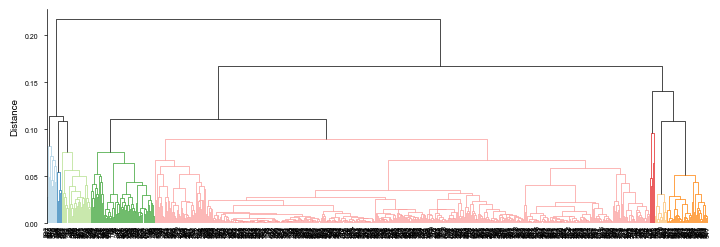

In [18]:
# Define the optimal number of clusters.
k_optimal = 8

# Compute hierarchical linkage.
linked = linkage(nichespace_deepsdm_all, method='average', metric='cosine')

# Generate cluster labels.
cluster_labels = fcluster(linked, t=k_optimal, criterion='maxclust')

# Determine distance threshold.
max_d = linked[-(k_optimal-1), 2]

# Plot the dendrogram.
fig, ax = plt.subplots(figsize=mm2inch(180, 60), constrained_layout = True)
set_link_color_palette(PU.color_list)
d_data = dendrogram(
    linked,
    orientation='top',
    distance_sort='ascending',
    show_leaf_counts=False,
    color_threshold=max_d,
    # labels=[sp.replace('_', ' ') for sp in PU.species_list_predict if sp not in species_list_exclude],
    # labels=[sp.replace('_', ' ') for sp in PU.species_list_predict],     # Use this line if no species_list_exclude
    above_threshold_color = 'black',
    ax = ax
)

# Adjust x-axis tick labels (species names), font size, italic style.
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 5, fontstyle='italic', rotation=90, ha='center', va = 'top')
ax.set_ylabel('Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set consistent line width on the dendrogram lines.
for line_collection in ax.collections:
    line_collection.set_linewidth(0.5)

# Adjust tick label spacing.
ax.tick_params(axis='x', which='major', pad=-1)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'nichespace_clustering_dendrogram.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/klok0126/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


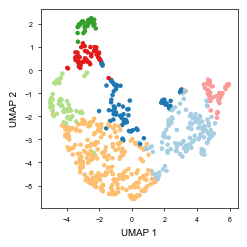

In [9]:
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, OPTICS, SpectralClustering
import matplotlib.pyplot as plt

X = nichespace_deepsdm_all  # 你的資料, e.g. shape (1256, 1505)
k_optimal = 7  # 你想要的群數

# kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
DBSCAN = KMeans(n_clusters=k_optimal, random_state=42)
cluster_labels = DBSCAN.fit_predict(X)

# labels 是與 X 同長度的一維 array，表示每個 species 的 cluster id
# print("cluster counts:", np.bincount(cluster_labels))

# 若你想畫 2D 可視化 (例如先降維再畫)
import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

plt.figure(figsize=mm2inch(60, 60), constrained_layout = True)
plt.scatter(embedding[:,0], embedding[:,1], c=np.array(PU.color_list)[cluster_labels], s=5)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
# plt.title(f'K-Means clustering (k={k_optimal}) on niche-space')
plt.savefig(os.path.join(PU.plot_path_nichespace_clustering, 'UMAP_cluster.pdf'), transparent = True, dpi = 500)
plt.show()

In [194]:
# from matplotlib import font_manager as fm

# # 設置字體為 Noto Sans CJK
# font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'  # 檢查該路徑是否存在
# font_prop = fm.FontProperties(fname=font_path)

# # Define the optimal number of clusters.
# k_optimal = 3

# # Compute hierarchical linkage.
# linked = linkage(nichespace_deepsdm_all, method='average', metric='cosine')

# # Generate cluster labels.
# cluster_labels = fcluster(linked, t=k_optimal, criterion='maxclust')

# # Determine distance threshold.
# max_d = linked[-(k_optimal-1), 2]

# # Plot the dendrogram.
# fig, ax = plt.subplots(figsize=mm2inch(180, 60), constrained_layout = True)
# set_link_color_palette(PU.color_list)
# d_data = dendrogram(
#     linked,
#     orientation='top',
#     distance_sort='ascending',
#     show_leaf_counts=False,
#     color_threshold=max_d,
#     labels=[get_chinese_sciname(sp) for sp in PU.species_list_predict if sp not in species_list_exclude],
#     above_threshold_color = 'black',
#     ax = ax
# )

# # Adjust x-axis tick labels (species names), font size, italic style.
# ls = [l.get_text() for l in ax.get_xticklabels()]
# vls = ['\n'.join(list(l)) for l in ls]
# ax.set_xticklabels(vls, fontsize = 4, ha='center', va = 'top', fontproperties = font_prop, rotation = 0)
# ax.set_ylabel('Distance')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# # Set consistent line width on the dendrogram lines.
# for line_collection in ax.collections:
#     line_collection.set_linewidth(0.5)

# # Adjust tick label spacing.
# ax.tick_params(axis='x', which='major', pad=-1)

# plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'nichespace_clustering_dendrogram_chinese.pdf')
# plt.savefig(plot_output, dpi = 500, transparent = True)
# plt.show()

## Generate cluster-level average niches
The following code computes the average niche map for each identified cluster.

In [10]:
all_cluster_avg_niches = PU.get_all_cluster_average_nichespace(cluster_labels, nichespace_deepsdm_all_nonflatten)
img_sign = np.sign(all_cluster_avg_niches[0][1])

## Write cluster labels and average niche space data
Stores the computed labels and averages to YAML files for subsequent usage.

In [11]:
with open(PU.cluster_labels_path, 'w') as f:
    yaml.dump(cluster_labels.tolist(), f)
    
all_cluster_avg_niches_converted = {int(i):j.tolist() for i, j in all_cluster_avg_niches}
with open(PU.cluster_avg_nichespace_path, 'w') as f:
    yaml.dump(all_cluster_avg_niches_converted, f)

## Visualization of average niche space per cluster
Here, each cluster's mean niche space is saved as an image.

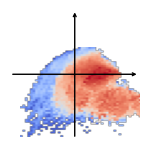

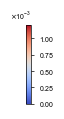

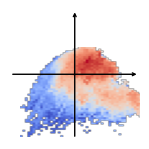

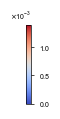

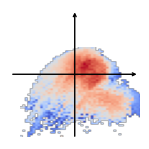

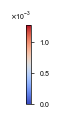

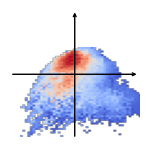

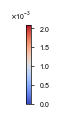

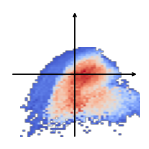

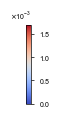

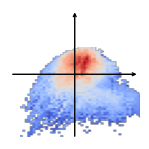

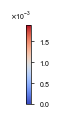

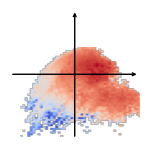

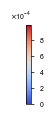

In [12]:
for (i_img, img) in all_cluster_avg_niches:
    fig, ax = plt.subplots(figsize = mm2inch(35, 35), constrained_layout = True)
    img_nan = np.where(img <= 0, np.nan, img)
    ax.imshow(img_nan, vmin = 0, cmap = 'coolwarm', extent = PU.nichespace_extent)
    ax.axis('off')

    # X-axis arrow.
    ax.annotate(
        '',
        xy=(6, 0),
        xytext=(-6, 0),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )

    # Y-axis arrow.
    ax.annotate(
        '',
        xy=(0, 6),
        xytext=(0, -6),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    plot_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_avg_cluster{i_img}.pdf')
    plt.savefig(plot_output, transparent = True, dpi = 500)
    plt.show()

    # Plot a separate colorbar for each cluster.
    fig_cb, ax_cb = plt.subplots(figsize = mm2inch(10, 25), gridspec_kw = {'left': 0.38, 'right': 0.5, 'bottom': 0.05, 'top': 0.85})
    norm = plt.Normalize(vmin = 0, vmax = np.nanmax(img_nan))
    cb = fig_cb.colorbar(plt.cm.ScalarMappable(norm = norm, cmap='coolwarm'), cax = ax_cb, orientation = 'vertical')

    formatter = mtick.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax_cb.yaxis.set_major_formatter(formatter)

    cb_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_avg_cluster{i_img}_colorbar.pdf')
    plt.savefig(cb_output, transparent=True, dpi=500)
    plt.show()

## Visualization of average niche space per cluster
Here, each cluster's mean niche space is saved as an image.

In [13]:
df_center = PU.calculate_deepsdm_nichespace_center(nichespace_deepsdm_all_nonflatten, cluster_labels)
df_center.to_csv(PU.df_nichespace_center_coordinate_path)
df_center

,PC01,PC02,cluster
Abies_kawakamii,0.972144,-1.530595,4
Acacia_caesia,1.405206,-0.959884,1
Acacia_confusa,0.693868,-1.267719,2
Acer_albopurpurascens,1.092946,-1.320434,6
Acer_caudatifolium,1.488097,-1.424844,0
...,...,...,...
Zanthoxylum_armatum,1.244838,-1.225436,6
Zanthoxylum_nitidum,0.798260,-1.212912,2
Zanthoxylum_scandens,1.128064,-1.349305,6
Zanthoxylum_schinifolium,1.374345,-0.702311,1


0
['尾葉灰木', '臺灣蘋果', '昆欄樹', '凹葉越橘', '臺灣絡石', '尖葉楓', '臺灣老葉兒樹', '假柃木', '臺灣鵝掌柴', '巒大紫珠', '正藤木槲', '臺灣馬醉木', '珍珠花', '栓皮櫟', '臺灣溲疏', '玉山箭竹', '臺灣掌葉槭', '疏果海桐', '玉山糯米樹', '厚葉柃木', '四川灰木', '南嶺灰木', '早田氏柃木', '白珠樹', '大葉越橘', '假繡球', '佩羅特木', '水絲梨', '臺灣赤楊', '阿里山女貞', '守城滿山紅', '臺灣粗榧', '小葉莢蒾', '早田氏冬青', '白花八角', '玉山杜鵑', '異葉木犀', '蘭邯千金榆', '長果紅淡比', '臺灣五葉松', '臺灣扁柏', '臺灣灰木', '山胡椒', '擬日本灰木', '深紅茵芋', '福建賽衛矛', '臺灣杜鵑', '紅檜', '著生珊瑚樹', '臺灣厚距花', '臺灣杉', '毛瓣石楠', '太平山冬青', '粗毛柃木', '阿里山忍冬', '小實女貞', '壺花莢蒾', '石楠', '阿里山五味子', '雪山冬青', '巒大越橘', '深山野牡丹', '光果南蛇藤', '阿里山灰木', '白新木薑子', '銳葉木犀', '褐毛灰木', '阿里山千金榆', '大葉石櫟', '臺灣青莢葉', '臺灣常春藤', '藤毛木槲', '臺灣藤漆', '鬼石櫟', '十大功勞', '變葉新木薑子', '圓葉冬青', '狹葉櫟', '臺灣羊桃', '野核桃', '太平山櫻花', '薄葉虎皮楠', '通條樹', '華參', '東瀛珊瑚', '臺灣黃鱔藤', '南澳杜鵑', '臺灣八角金盤', '南燭', '臺東莢蒾', '森氏鐵線蓮', '刺果衛矛', '霧社木薑子', '高山莢蒾', '賽山椒', '桑葉懸鉤子', '忍冬葉冬青', '薄葉灰木', '毽子櫟', '臺灣瑞香', '大葉海桐', '東方肉穗野牡丹', '泛能高山茶', '蘭崁馬藍', '臺灣水青岡', '月桂葉灰木', '枇杷葉灰木', '白花瑞香', '布勒德藤', '銳葉新木薑子', '臺灣檫樹', '玉山木薑子', '紫珠葉泡花', '臺灣二葉松', '臺灣懸鉤子', '毛蕊花', '大葉馬兜鈴', '狹葉莢蒾', '玉山灰木', '高山新木薑子', '太平紅淡比

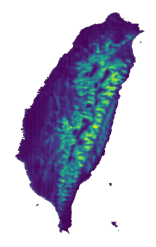

1
['李氏木薑子', '柳葉山茶', '山柿', '大武新木薑子', '雨傘仔', '牛樟', '港口木荷', '魚藤', '小葉雞屎樹', '疏花魚藤', '叢花百日青', '高氏木犀', '通脫木', '松田氏冬青', '羅氏鹽膚木', '山桐子', '藤相思樹', '尾葉山茶', '黃土樹', '合歡', '假酸漿', '茶葉灰木', '大葉南蛇藤', '山黃皮', '翼柄花椒', '銳葉山柑', '能漢木薑子', '冇骨消', '臺灣山茶', '子彈石櫟', '假黃楊', '構樹', '厚殼樹', '菲律賓楠', '野山椒', '薄葉玉心花', '黃連木', '無脈木犀', '桶鉤藤', '火燒柯', '長穗馬藍', '化香樹', '小芽新木薑子', '青皮木', '俄氏柿', '車桑子', '大葉苦櫧', '長序木通', '楝', '馬銀花', '光葉魚藤', '星刺栲', '屏東木薑子', '中原氏鼠李', '垂絲衛矛', '小西氏楠', '山葛', '菱果石櫟', '楊桐葉灰木', '石斑木', '臺灣欒樹', '臺灣苦櫧', '櫸', '後大埔石櫟', '珊瑚樹', '蓮花池山龍眼', '阿里山紫金牛', '銳脈木薑子', '銀合歡', '臺灣梭羅樹', '糙葉樹', '秀柱花', '交力坪鐵色', '太魯閣櫟', '紫珠', '灰背葉紫珠', '食茱萸', '臺灣山豆根']
['Litsea_lii_var._lii', 'Camellia_salicifolia', 'Diospyros_japonica', 'Neolitsea_daibuensis', 'Ardisia_cornudentata_subsp._cornudentata', 'Camphora_kanahirae', 'Schima_superba_var._kankaoensis', 'Derris_elliptica', 'Lasianthus_microphyllus', 'Derris_laxiflora', 'Podocarpus_fasciculus', 'Osmanthus_kaoi', 'Tetrapanax_papyriferus', 'Ilex_lonicerifolia_var._matsudae', 'Rhus_javanica_var._roxbur

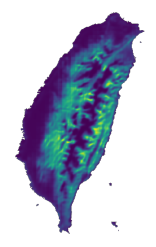

2
['雙面刺', '竹柏', '臺灣鉤藤', '圓果青剛櫟', '武靴藤', '青楊梅', '筆羅子', '灰木', '苦茶', '銳葉紫珠', '臺灣清風藤', '文山雞屎樹', '密花五月茶', '烏皮茶', '黃荊', '鐘萼木', '廣東山葡萄', '菱葉衛矛', '臭黃荊', '裏白瓜馥木', '蚊母樹', '南投五月茶', '朱紅水木', '烏臼', '土楠', '大葉密毛雞屎樹', '琉球黃楊', '長葉繡球', '厚葉衛矛', '錫蘭饅頭果', '茜草樹', '白桕', '菲律賓榕', '鼠刺', '白背櫟', '蟲屎', '單刺苦櫧', '臺灣芭蕉', '密毛雞屎樹', '扛香藤', '柯氏雞屎樹', '稜果榕', '魯花樹', '密毛假黃楊', '棶木', '大花曼陀羅', '野鴉椿', '臺灣肖楠', '七里香', '山刈葉', '相思樹', '大錦蘭', '蒲桃', '枯里珍', '千年桐', '細葉蚊母樹', '魚木', '黃楊', '瓜馥木', '臺灣假黃楊', '山露兜', '光葉柃木', '倒卵葉冬青', '小錦蘭', '榕樹', '烏來柯', '白毛臭牡丹', '紅仔珠']
['Zanthoxylum_nitidum', 'Nageia_nagi', 'Uncaria_hirsuta', 'Quercus_globosa', 'Gymnema_sylvestre', 'Myrica_adenophora', 'Meliosma_rigida', 'Symplocos_chinensis', 'Camellia_oleifera', 'Callicarpa_tikusikensis', 'Sabia_swinhoei', 'Lasianthus_bunzanensis', 'Antidesma_japonicum_var._densiflorum', 'Pyrenaria_shinkoensis', 'Vitex_negundo', 'Bretschneidera_sinensis', 'Nekemias_cantoniensis', 'Euonymus_tashiroi', 'Premna_microphylla', 'Fissistigma_glaucescens', 'Distylium_racemosum', 'Antide

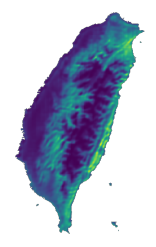

3
['紅柴', '檬果', '十子木', '武威新木薑子', '繖楊', '蓮葉桐', '南嶺蕘花', '土樟', '大野牡丹', '南仁五月茶', '山欖', '恆春石斑木', '紅雞油', '高士佛赤楠', '華茜草樹', '浸水營石櫟', '露兜樹', '克蘭樹', '小葉樟', '黃槿', '烏柑仔', '火筒樹', '臺灣馬錢', '南仁新木薑子', '細脈赤楠', '疏齒紫珠', '革葉冬青', '大果藤榕', '毛柿', '恆春楨楠', '大葉樹蘭', '細葉茶梨', '瓊崖海棠', '恆春紅豆樹']
['Aglaia_formosana', 'Mangifera_indica', 'Decaspermum_gracilentum', 'Neolitsea_buisanensis_fo._buisanensis', 'Thespesia_populnea', 'Hernandia_nymphiifolia', 'Wikstroemia_indica', 'Cinnamomum_reticulatum', 'Astronia_formosana', 'Antidesma_hiiranense', 'Planchonella_obovata', 'Rhaphiolepis_indica_var._hiiranensis', 'Ulmus_parvifolia', 'Syzygium_kusukusense', 'Randia_sinensis', 'Lithocarpus_shinsuiensis', 'Pandanus_odorifer', 'Kleinhovia_hospita', 'Cinnamomum_brevipedunculatum', 'Hibiscus_tiliaceus', 'Severinia_buxifolia', 'Leea_guineensis', 'Strychnos_cathayensis', 'Neolitsea_hiiranensis', 'Syzygium_euphlebium', 'Callicarpa_remotiserrulata', 'Ilex_cochinchinensis', 'Ficus_punctata', 'Diospyros_philippensis', 'Machilus_obovatifolia

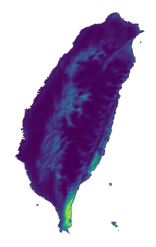

4
['玉山假沙梨', '臺灣小檗', '松田氏莢蒾', '布氏稠李', '鈍齒鼠李', '霧社山櫻花', '樺葉莢蒾', '藤繡球', '臺灣華山松', '鞍馬山越橘', '阿里山茶', '玉山小檗', '臺灣吊鐘花', '笑靨花', '阿里山櫻花', '雲南冬青', '長葉小檗', '褐毛柳', '臺灣馬桑', '小葉鼠李', '臺灣黃杉', '阿里山十大功勞', '巒大花楸', '長卵葉馬銀花', '畢祿山鼠李', '擬烏蘇里瓦葦', '臺灣雲杉', '紅毛杜鵑', '薄葉柳', '臺灣冷杉', '南湖杜鵑', '刺柏', '高山櫟', '苗栗冬青', '棲蘭山杜鵑', '高山白珠樹', '細葉杜鵑', '冬青葉桃仁', '能高山灰木', '亞蹄蓋蕨', '假皂莢', '阿里山茵芋', '南洋紅豆杉', '刺葉桂櫻', '鈴木冬青', '香青', '臺灣茶藨子', '刻脈冬青', '高山藤繡球', '銳葉高山櫟', '臺灣鐵杉', '大武杜鵑']
['Photinia_niitakayamensis', 'Berberis_kawakamii', 'Viburnum_erosum', 'Prunus_buergeriana', 'Rhamnus_crenata', 'Prunus_taiwaniana', 'Viburnum_betulifolium', 'Hydrangea_anomala', 'Pinus_armandii_var._mastersiana', 'Vaccinium_kengii', 'Camellia_transarisanensis', 'Berberis_morrisonensis', 'Enkianthus_perulatus', 'Spiraea_prunifolia', 'Prunus_transarisanensis', 'Ilex_yunnanensis', 'Berberis_aristatoserrulata', 'Salix_fulvopubescens_var._fulvopubescens', 'Coriaria_japonica_subsp._intermedia', 'Rhamnus_parvifolia', 'Pseudotsuga_wilsoniana', 'Mahonia_oiwakensis', 'So

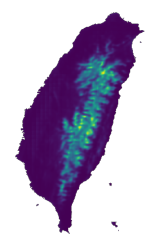

5
['多花油柑', '長葉厚殼樹', '印度苦櫧', '天臺烏藥', '恆春厚殼樹', '土密樹', '華河瓊楠', '捲斗櫟', '小構樹', '波葉櫟', '馬櫻丹', '水柳', '臺灣紅豆樹', '羊蹄甲', '裏白巴豆', '紅果椌木', '桃實百日青', '腺果藤', '裏白菝葜', '龍眼', '希蘭灰木', '小葉朴', '荔枝', '山柚', '嶺南青剛櫟', '土藤', '狹葉木薑子', '灰背櫟', '壺冠木', '郭氏錐果櫟', '白榕', '恆春福木', '毛雞屎樹', '天料木', '南洋桫欏', '杉木', '銹葉灰木', '太魯閣千金榆', '能高山茶', '疏花紫珠', '小刺山柑', '山柑', '柳葉石櫟', '東亞八角', '多花山柑', '水錦樹', '樹薯', '烏心石舅', '臺灣穗花杉', '佐佐木氏灰木', '橢圓葉木薑子', '細刺苦櫧']
['Phyllanthus_reticulatus', 'Ehretia_longiflora', 'Castanopsis_indica', 'Lindera_aggregata_var._aggregata', 'Ehretia_resinosa', 'Bridelia_tomentosa', 'Beilschmiedia_tsangii', 'Quercus_pachyloma', 'Broussonetia_monoica', 'Quercus_repandifolia', 'Lantana_camara', 'Salix_warburgii', 'Ormosia_formosana', 'Bauhinia_variegata', 'Croton_cascarilloides', 'Dysoxylum_hongkongense', 'Podocarpus_nakaii', 'Pisonia_aculeata', 'Smilax_corbularia', 'Dimocarpus_longan', 'Symplocos_shilanensis', 'Celtis_nervosa', 'Litchi_chinensis', 'Champereia_manillana', 'Quercus_championii', 'Calamus_beccarii', 'Litsea_ak

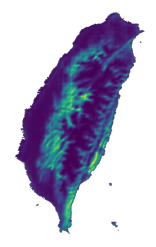

6
['青剛櫟', '小葉石楠', '山香圓', '裡白懸鉤子', '臺灣赤楠', '長梗紫麻', '野牡丹', '臺灣楊桐', '斯氏懸鉤子', '長葉苧麻', '杏葉石櫟', '柞木', '大葉木犀', '秦椒', '小葉樹杞', '山黃梔', '厚皮香', '血桐', '臺灣馬藍', '胡氏肉桂', '山豬肝', '香葉樹', '油葉石櫟', '奧氏虎皮楠', '狹瓣八仙花', '穿鞘花', '鵲不踏', '樹杞', '漢氏山葡萄', '地錦', '澀葉榕', '水團花', '白匏子', '小葉木犀', '軟毛柿', '假菝葜', '內苳子', '日本女貞', '臺灣胡頹子', '樟樹', '臺灣糊樗', '馬藍', '木荷', '珍珠蓮', '杜虹花', '三腳虌', '大明橘', '小葉赤楠', '藤花椒', '小西氏灰木', '柱果鐵線蓮', '菝葜', '綠樟', '香楠', '水麻', '玉山紫金牛', '盤龍木', '猿尾藤', '三葉山香圓', '拎樹藤', '錐果櫟', '黃肉樹', '拎壁龍', '糙莖菝葜', '黑星紫金牛', '粗糠柴', '紅淡比', '野桐', '臺灣土茯苓', '青楓', '鵝掌柴', '山桂花', '細葉饅頭果', '石苓舅', '臺灣牛彌菜', '呂宋莢蒾', '筆筒樹', '土肉桂', '菊花木', '烏皮九芎', '南華南蛇藤', '豬母乳', '朴樹', '假赤楊', '山羊耳', '豬腳楠', '九節木', '燈稱花', '頷垂豆', '細梗絡石', '裏白饅頭果', '五節芒', '紅子莢蒾', '石朴', '鹿皮斑木薑子', '雀榕', '白雞油', '黃藤', '冇樟', '菲律賓饅頭果', '紅葉樹', '南五味子', '臺灣樹參', '白肉榕', '長葉木薑子', '薯豆', '短柱山茶', '薄葉風藤', '紅皮', '臺灣山桂花', '森氏紅淡比', '海金沙', '臺灣石楠', '猴歡喜', '金石榴', '毛玉葉金花', '米碎柃木', '鬼桫欏', '細枝柃木', '瓊楠', '草珊瑚', '大葉楠', '臺灣梣', '大青', '咬人狗', '山黃麻', '青苧麻', '油桐', '杜英', '黃杞', '銳葉柃木', '日本雞屎樹', '臺灣八角', '串鼻龍', '伏牛花', '

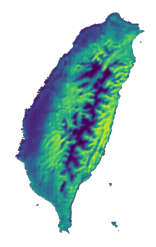

In [14]:
df_change_name = pd.read_csv(os.path.join(PU.plot_path_nichespace_clustering, 'change_name.csv'))
df_center['chinese_name'] = [df_change_name[df_change_name.sciname == sp.replace('_', ' ')].chiname.values[0] for sp in df_center.index.tolist()]
df_center.to_csv(os.path.join(PU.plot_path_nichespace_clustering, 'nichecenter_coordinate_chinese.csv'))

import random
import h5py
for cluster in set(df_center.cluster):
    print(cluster)
    sp_avg_cluster_distribution = np.zeros([PU.height, PU.width])
    sp_list_cluster = df_center[df_center.cluster==cluster].index.tolist()
    sp_list_cluster_random = random.sample(sp_list_cluster, min(250, len(sp_list_cluster)))
    print([df_center[df_center.index==sp].chinese_name.values[0] for sp in sp_list_cluster_random])
    print(sp_list_cluster_random)
    for sp in sp_list_cluster_random:
        sp_avg_distribution = np.zeros([PU.height, PU.width])
        with h5py.File(PU.deepsdm_h5_path.replace('[SPECIES]', sp), 'r') as h5f:
            for key in h5f.keys():
                sp_avg_distribution = sp_avg_distribution + h5f[key][:]
            sp_avg_distribution = sp_avg_distribution/len(h5f.keys())
            
        sp_avg_cluster_distribution = sp_avg_cluster_distribution + sp_avg_distribution
    sp_avg_cluster_distribution = sp_avg_cluster_distribution / len(sp_list_cluster_random)
    fig, ax = plt.subplots(figsize = mm2inch(40, 60), constrained_layout = True)
    ax.imshow(sp_avg_cluster_distribution)
    ax.axis('off')
    fig_path = os.path.join(PU.plot_path_nichespace_clustering, f'biotope_cluster{cluster}.pdf')
    plt.savefig(fig_path)
    plt.savefig(cb_output, transparent=True, dpi=500)
    plt.show()

## Compute LDA of clustered niche centers

In [110]:
df_lda_result, df_ldaonPC, lda_explained_ratio, k_fold_validation = PU.calculate_nichecenter_cluster_lda()
df_lda_result

Stratified 5-fold CV accuracy: 0.768 (± 0.026)


,variable,importance_pc,loading_PC1,loading_PC2,proj_on_LD1,proj_on_LD2
0,rsds,3.238489e-01,-0.537032,0.717218,-0.802242,0.146051
1,EVI,1.930002e-01,0.472394,0.612831,-0.517685,0.769290
2,tas,1.784091e-01,-0.437249,0.526244,-0.596415,0.077256
3,sfcWind,1.222944e-01,-0.402104,-0.487190,0.406765,-0.629953
4,pr,7.747510e-02,0.591127,0.366383,-0.253878,0.673567
5,clt,6.176728e-02,0.861204,-0.112536,0.265866,0.514778
6,hurs,3.611247e-02,0.750239,-0.001479,0.136633,0.518147
7,landcover_PC01,6.896807e-03,0.334892,0.032108,0.028758,0.254944
8,landcover_PC02,1.047416e-04,0.030225,0.011736,-0.006098,0.029389
9,landcover_PC04,9.072075e-05,0.016121,0.012985,-0.009868,0.020530


In [65]:
df_ldaonPC.LD1.PC02 / df_ldaonPC.LD1.PC01

-1.193965359275491

## Overlap visualization of average clusters in niche space
Combines the top 50% density areas of each cluster's average niche, plus PCA loadings vectors.

In [66]:
unique_labels, label_to_color = PU.align_label_to_color(k_optimal, cluster_labels)

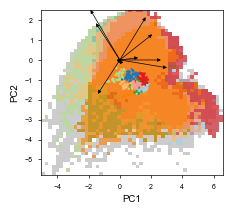

In [67]:
fig, ax = plt.subplots(figsize=mm2inch(55, 50), 
                       gridspec_kw = {'left': 0.15, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Display the background mask (significant region) in grey with transparency
ax.imshow(np.where(img_sign == 1, img_sign, np.nan),
          alpha=0.4,
          extent=PU.nichespace_extent,
          cmap=ListedColormap('grey'))
ax.set_aspect('auto')

# Overlay each cluster’s average niche region
for i_cluster, lbl in enumerate(unique_labels):
    # Get average niche map for the current cluster
    cluster_i_avg_niche = np.where(all_cluster_avg_niches[i_cluster][1] > 0,
                                   all_cluster_avg_niches[i_cluster][1],
                                   np.nan)
    # Define the threshold (50th percentile of non-NaN values)
    cluster_i_threshold = np.nanpercentile(cluster_i_avg_niche, 50)
    
    # Create a single-color colormap for this cluster
    single_cmap = ListedColormap([label_to_color[int(lbl)]]).copy()
    single_cmap.set_bad(alpha=0)
    
    # Display the thresholded cluster region
    ax.imshow(np.where(cluster_i_avg_niche >= cluster_i_threshold, 1, np.nan),
              extent=PU.nichespace_extent,
              cmap=single_cmap,
              alpha=0.6)
    ax.set_aspect('auto')

# Draw environmental variable vectors from the origin
for env in PU.env_list:
    dx = PU.env_pca_loadings.loc[env][f'PC{PU.x_pca:02d}'] * 3.5
    dy = PU.env_pca_loadings.loc[env][f'PC{PU.y_pca:02d}'] * 3.5
    ax.annotate(
        '',                              # No text, just an arrow
        xy=(dx, dy),                     # Arrow tip (end)
        xytext=(0, 0),                   # Arrow base (start)
        arrowprops=dict(
            arrowstyle='-|>',            # Arrowhead style
            lw=0.5,                      # Line width
            mutation_scale=5,            # Scale factor for arrowhead size (pt)
            fc='black',                  # Fill color (black)
            shrinkA=0,
            shrinkB=0
        )
    )

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Scatter plot of species niche centroids, colored by cluster label
point_colors = [label_to_color[int(lbl)] for lbl in cluster_labels]
ax.scatter(x=df_center['PC01'],
           y=df_center['PC02'],
           c=point_colors,
           s=0.5)

# Save figure as a transparent high-resolution PDF
plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'cluster_mean_env.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)

# Display the final figure
plt.show()

## Plot species niche centroids and the largest variance direction
Scatter plot of species-level PC1 vs PC2 plus a dashed line representing direction of maximum variance.

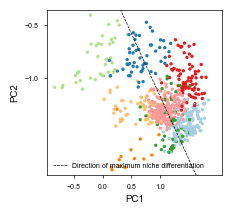

In [68]:
fig, ax = plt.subplots(figsize=mm2inch(55, 50), 
                       gridspec_kw = {'left': 0.18, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Scatter plot of species niche centroids in environmental PCA space
ax.scatter(x=df_center['PC01'],
           y=df_center['PC02'],
           c=point_colors,
           s=2)

# Calculate the centroid of all points (used to center the line of maximum variation)
center_x = df_center["PC01"].mean()
center_y = df_center["PC02"].mean()

# Compute and plot the line representing the direction of maximum variation among species niche centroids
# Equation: y = slope * (x - center_x) + center_y
x_vals_shifted = np.linspace(df_center["PC01"].min(), df_center["PC01"].max()+0.1, 100)
y_vals_shifted = df_ldaonPC.LD1.PC02 / df_ldaonPC.LD1.PC01 * (x_vals_shifted - center_x) + center_y

ax.plot(x_vals_shifted, y_vals_shifted,
        color="black",
        linestyle="--",
        linewidth=0.5,
        label="Direction of maximum niche differentiation")

# Add legend
ax.legend(loc='lower left', frameon=False)

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Define tick positions for both axes
ax.set_xticks([-0.5, 0, 0.5, 1])
ax.set_yticks([-1.0, -0.5])

# Set y-axis range slightly beyond data limits for better spacing
ax.set_ylim([df_center["PC02"].min() - 0.05,
             df_center["PC02"].max() + 0.05])

# Save figure as a transparent high-resolution PDF
plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'niche_center_LDAaxis1.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)

# Display plot
plt.show()


## Plot importance of environmental factors of LDA
Displays the importance of each environmental factor to LDA result.

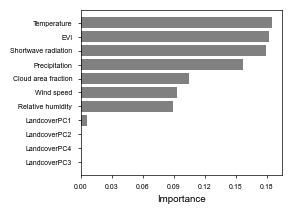

In [17]:
fig, ax = plt.subplots(figsize=mm2inch(70, 50), 
                       gridspec_kw = {'left': 0.26, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Get y-axis labels (according to the mapping in env_list_change dictionary)
y_labels = convert_to_env_list_detail(df_lda_result.variable)

# Plot each bar
for i, (env, value) in enumerate(zip(df_lda_result.variable,
                                     df_lda_result.importance_pc)):
    ax.barh(y_labels[i], value, color="grey")

# Set x-axis label
ax.set_xlabel("Importance")

# Set custom x-axis ticks
ax.set_xticks([0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Invert y-axis to show the most correlated variable at the top
ax.invert_yaxis()

# Remove background grid lines
ax.grid(False)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'lda_importance.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)
plt.show()

## Environmental medians violin plots of species among three clusters

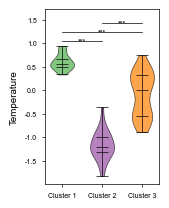

Overall Kruskal–Wallis (3 clusters): H=86.485, p=1.66e-19
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=40.179, p=2.32e-10
  Cluster 1 vs Cluster 3: H=47.837, p=4.63e-12
  Cluster 2 vs Cluster 3: H=49.211, p=2.3e-12
[Saved] Updated results for 'tas' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


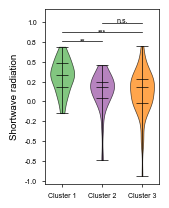

Overall Kruskal–Wallis (3 clusters): H=13.329, p=0.00128
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=8.650, p=0.00327
  Cluster 1 vs Cluster 3: H=11.769, p=0.000602
  Cluster 2 vs Cluster 3: H=0.038, p=0.845
[Saved] Updated results for 'rsds' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


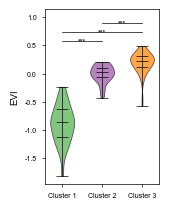

Overall Kruskal–Wallis (3 clusters): H=79.405, p=5.72e-18
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=39.326, p=3.59e-10
  Cluster 1 vs Cluster 3: H=60.251, p=8.35e-15
  Cluster 2 vs Cluster 3: H=23.653, p=1.15e-06
[Saved] Updated results for 'EVI' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


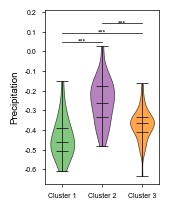

Overall Kruskal–Wallis (3 clusters): H=34.011, p=4.12e-08
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=23.534, p=1.23e-06
  Cluster 1 vs Cluster 3: H=11.987, p=0.000536
  Cluster 2 vs Cluster 3: H=19.135, p=1.22e-05
[Saved] Updated results for 'pr' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


In [19]:
species_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
# for env in PU.env_list:
for env in ['tas', 'rsds', 'EVI', 'pr']:
    PU.species_occ_env_violinplot(env, species_exclude)